## Chapter-06: Decision Trees

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [6]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [7]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file=str(IMAGES_PATH / "iris_tree.dot"),
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

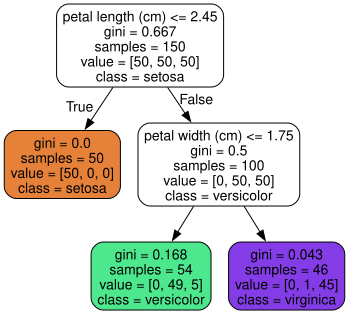

In [8]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")

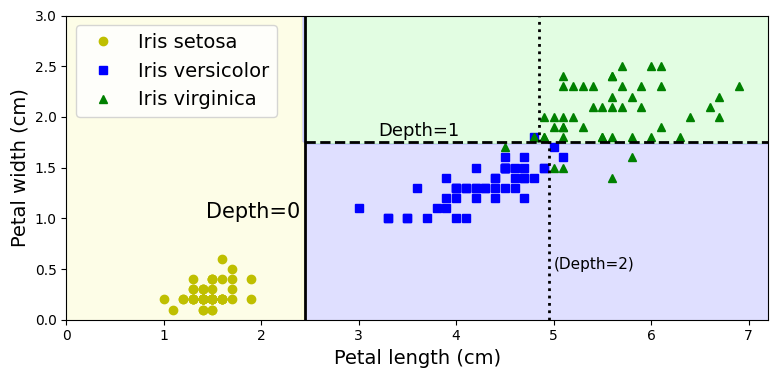

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# extra code – just formatting details
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# extra code – this section beautifies and saves Figure 6–2
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()
save_fig("decision_tree_decision_boundaries_plot")

plt.show()

## Regularization Hyperparameters

In [10]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(max_depth=2, random_state=42)

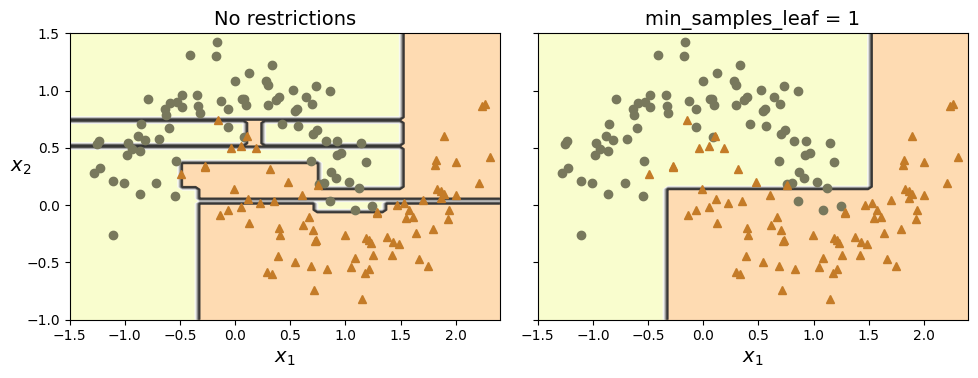

In [11]:
# extra code – this cell generates and saves Figure 6–3

def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
save_fig("min_samples_leaf_plot")
plt.show()

In [12]:
X_moons[21]

array([ 1.74809254, -0.53395565])

In [13]:
y_moons[21]

np.int64(1)

In [14]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf2,
    out_file=str(IMAGES_PATH / "make_moons.dot"),
    feature_names=["X1", "X2"],
    class_names=["Class 0", "Class 1"],
    rounded=True,
    filled=True
)

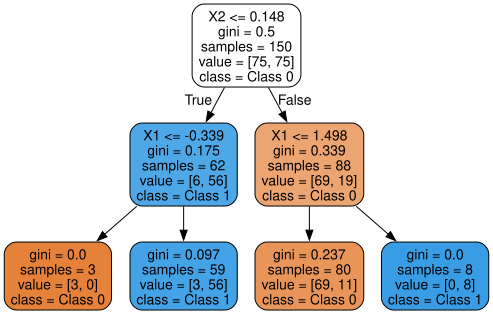

In [15]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "make_moons.dot")  # path differs in the book

## Hybrid Models(Decision Tree + Logistic Regression) Vs Decision Tree

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

In [17]:
# Generate a circular dataset
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==============================================
# Hybrid Model: Decision Tree + Logistic Regression
# ==============================================
# Step 1: Train a shallow Decision Tree to split the space into regions
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

# Step 2: Use the tree's leaf nodes as features (one-hot encoding)
leaf_ids_train = tree.apply(X_train)  # Get leaf node IDs for training data
leaf_ids_test = tree.apply(X_test)    # Get leaf node IDs for test data

# One-hot encode the leaf IDs
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = encoder.fit_transform(leaf_ids_train.reshape(-1, 1))
X_test_encoded = encoder.transform(leaf_ids_test.reshape(-1, 1))

# Step 3: Train Logistic Regression on the encoded features
logistic = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000)
logistic.fit(X_train_encoded, y_train)

# ==============================================
# Compare with standalone models
# ==============================================
# Standalone Logistic Regression (will fail)
lr = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
lr.fit(X_train, y_train)

# Standalone Decision Tree (may overfit)
deep_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
deep_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [18]:
# ==============================================
# Evaluate all models
# ==============================================
def evaluate(model, X_train, X_test, name):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"{name}:")
    print(f"  Train Accuracy: {accuracy_score(y_train, y_pred_train):.3f}")
    print(f"  Test Accuracy:  {accuracy_score(y_test, y_pred_test):.3f}\n")

evaluate(logistic, X_train_encoded, X_test_encoded, "Hybrid Model")
evaluate(lr, X_train, X_test, "Standalone Logistic Regression")
evaluate(deep_tree, X_train, X_test, "Standalone Deep Tree")

Hybrid Model:
  Train Accuracy: 0.987
  Test Accuracy:  0.957

Standalone Logistic Regression:
  Train Accuracy: 0.610
  Test Accuracy:  0.553

Standalone Deep Tree:
  Train Accuracy: 0.994
  Test Accuracy:  0.957



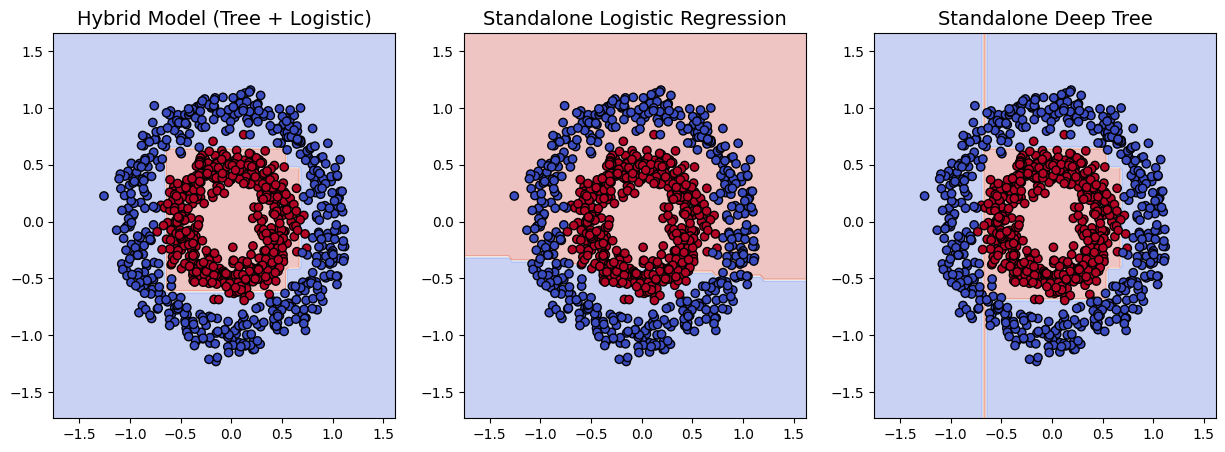

In [19]:
# ==============================================
# Plot decision boundaries
# ==============================================
def plot_decision_boundary(model, X, y, title, hybrid=False):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    if hybrid:
        # For hybrid model: convert meshgrid points to tree leaves first
        leaf_ids = tree.apply(np.c_[xx.ravel(), yy.ravel()])
        Z = model.predict(encoder.transform(leaf_ids.reshape(-1, 1)))
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    plt.title(title)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plot_decision_boundary(logistic, X, y, "Hybrid Model (Tree + Logistic)", hybrid=True)
plt.subplot(1, 3, 2)
plot_decision_boundary(lr, X, y, "Standalone Logistic Regression")
plt.subplot(1, 3, 3)
plot_decision_boundary(deep_tree, X, y, "Standalone Deep Tree")
plt.show()

In [20]:
logistic.intercept_, logistic.coef_

(array([-1.52825806]),
 array([[-2.21961384,  0.68154831, -0.38796711, -1.98550999,  1.52223916,
          5.45419092, -0.0367064 , -1.82278748, -0.75581339,  2.74662703,
         -0.94843307, -0.94843307,  0.68154831, -2.09460683]]))

In [21]:
1 / (1 + np.exp(-(logistic.intercept_ + logistic.coef_)))

array([[0.02302519, 0.30012352, 0.1282831 , 0.02892302, 0.49849528,
        0.98065777, 0.17293543, 0.03386094, 0.09245078, 0.77177639,
        0.07750846, 0.07750846, 0.30012352, 0.0260114 ]])

## Accessing the tree structure

In [26]:
tree = tree_clf.tree_ # "tree_" is used to store the tree structure

In [29]:
print("[+] Max-depth of tree: ", tree.max_depth)
print("[+] Total Number of Nodes in tree: ", tree.node_count)
print("[+] Number of Leaves in tree: ", tree.n_leaves)

[+] Max-depth of tree:  2
[+] Total Number of Nodes in tree:  5
[+] Number of Leaves in tree:  3


In [32]:
print("[+] Number of features: ", tree.n_features)
print("[+] Number of classes: ", tree.n_classes)
print("[+] Number of outputs: ", tree.n_outputs)

[+] Number of features:  2
[+] Number of classes:  [3]
[+] Number of outputs:  1


In [34]:
# All the information about nodes is stored in numpy arrays.
# The root node is stored at index 0. The left and right children of the node are stored at index tree.children_left[node_index] and tree.children_right[node_index] respectively.
# The feature used to split the node is stored at index tree.feature[node_index].
# The threshold value used to split the node is stored at index tree.threshold[node_index].
# The number of samples in the node is stored at index tree.n_node_samples[node_index].
# The impurity of the node is stored at index tree.impurity[node_index].
# The value of the node is stored at index tree.value[node_index].

array([0.66666667, 0.        , 0.5       , 0.16803841, 0.04253308])